# Parameter Sensitivity Analysis

This notebook studies how the structural parameters of the generated book affect the estimated compiled page count, using a one-at-a-time (OAT) sweep, a finite-difference partial-derivative index, and a lean/baseline/rich configuration comparison (guideline 9). The deterministic analysis logic lives in `bookgen.research.sensitivity` and is unit-tested; this notebook is the presentation layer.

## Page-Count Model

We estimate the compiled page count as

$$\hat{P} = \left\lceil \frac{C \cdot S \cdot W}{450} \right\rceil + 3$$

where $C$ is the number of chapters, $S$ the sections per chapter, and $W$ the words per section. The constant $3$ accounts for front matter (cover, table of contents, figures, table, and formula).

In [1]:
from bookgen.sdk import BookGenSDK

# Guideline 4.1: drive the research analysis through the single SDK entry point.
sdk = BookGenSDK()
analysis = sdk.run_sensitivity_analysis()
results = analysis["oat"]
for parameter, series in results.items():
    print(parameter, series)

chapters [(3, 8), (4, 10), (5, 12), (6, 13), (7, 15), (8, 17), (9, 18), (10, 20)]
sections [(2, 10), (3, 13), (4, 17), (5, 20), (6, 23)]
words [(150, 9), (200, 11), (250, 13), (300, 15), (350, 17), (400, 19), (450, 21)]


## Partial-Derivative Sensitivity

Ignoring the ceiling, $\hat{P}$ is multilinear in the parameters, so the partial derivatives at the baseline $(C_0, S_0, W_0) = (6, 3, 250)$ are

$$\frac{\partial \hat{P}}{\partial C} = \frac{S_0 W_0}{450}, \quad \frac{\partial \hat{P}}{\partial S} = \frac{C_0 W_0}{450}, \quad \frac{\partial \hat{P}}{\partial W} = \frac{C_0 S_0}{450}.$$

We approximate these numerically with a symmetric finite difference, and also compare three end-to-end configurations.

In [2]:
print('partial sensitivities:', analysis["partials"])
print('configuration comparison (pages):', analysis["comparison"])

partial sensitivities: {'chapters': 1.5, 'sections': 3.5, 'words': 0.5}
configuration comparison (pages): {'lean': 7, 'baseline': 13, 'rich': 28}


## Visualizations

The following call renders six figures concurrently under `generated/research/`: an OAT line chart, a sensitivity-magnitude bar chart, a scatter plot, a box plot, a heatmap of estimated pages over (chapters x words-per-section), and a waterfall of cumulative page contributions. Every figure uses a colorblind-safe palette and labeled axes/legend.

In [3]:
figure_paths = sdk.generate_sensitivity_figures()
for path in figure_paths:
    print(path)

generated\research\oat_lines.png
generated\research\sensitivity_bars.png
generated\research\complexity_scatter.png
generated\research\pages_boxplot.png
generated\research\pages_heatmap.png
generated\research\waterfall.png


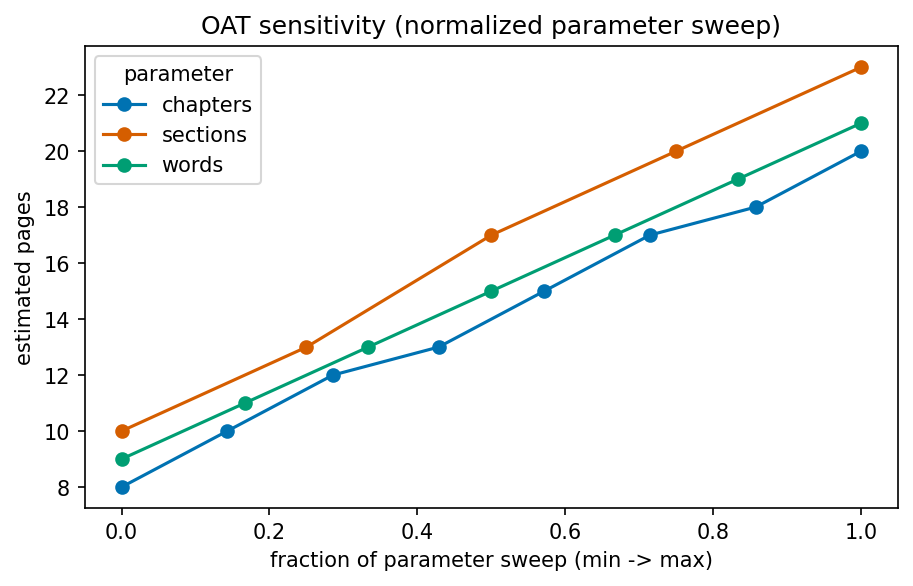

In [4]:
from IPython.display import Image

Image(filename=str(figure_paths[0]))

## Interpretation

Both the partial-derivative index and the sensitivity-magnitude bar chart agree
that **sections per chapter** has the largest single-parameter effect on length.
At the baseline $(C_0, S_0, W_0) = (6, 3, 250)$ the partial derivatives are
$\partial\hat{P}/\partial S = 3.5$, $\partial\hat{P}/\partial C = 1.5$, and
$\partial\hat{P}/\partial W = 0.5$ pages per unit, and the per-parameter sweep
range is $13$ pages for sections versus $12$ for chapters and $12$ for words.

Words per section has the *smallest* per-unit effect; it only covers a wide span
of pages because its sweep ranges over a much broader interval ($150$–$450$) than
chapters ($3$–$10$) or sections ($2$–$6$). Plotting the raw values on a shared
x-axis would therefore exaggerate `words`; the OAT line chart instead uses a
**normalized sweep fraction** so the three curves are comparable, and the
steepest curve is `sections`, consistent with the partial-derivative ranking.

The heatmap shows the chapters × words-per-section interaction: the ~$13$-page
baseline target is reached across a broad band, confirming the chosen baseline
(6 chapters, 3 sections, ~250 words) sits comfortably in range. The
lean/baseline/rich comparison ($7$ / $13$ / $28$ pages) shows the design scales
monotonically with content size.

## References

- A. Saltelli, M. Ratto, T. Andres, et al., *Global Sensitivity Analysis: The Primer*, Wiley, 2008 — variance-based and one-at-a-time (OAT) sensitivity methodology.
- M. D. Morris, "Factorial sampling plans for preliminary computational experiments," *Technometrics*, 33(2), 161–174, 1991 — the elementary-effects (OAT) screening method.
- I. M. Sobol', "Global sensitivity indices for nonlinear mathematical models and their Monte Carlo estimates," *Mathematics and Computers in Simulation*, 55(1–3), 271–280, 2001 — variance-based sensitivity indices.
- Course materials, Lesson L06 (parameter research and sensitivity analysis); submission guidelines, Section 9 (research and results analysis).